In [3]:
import numpy as np
from matplotlib import pyplot as plt
import torch

In [ ]:
# Data load
data=np.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/data/2026_03_18_CFRP_FBH_5s_30s_top_symetrical.npz",allow_pickle=True)

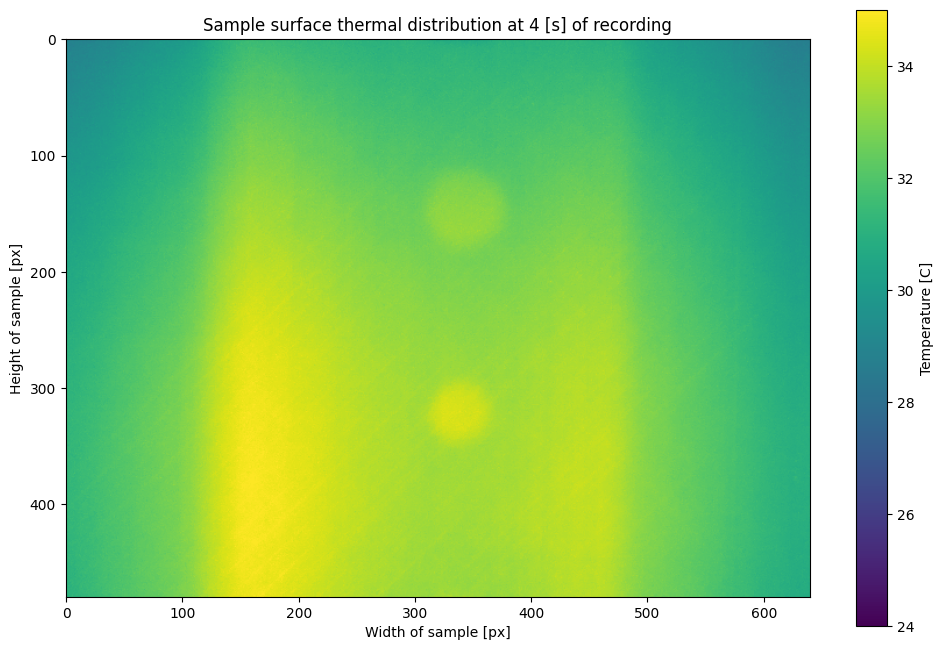

In [23]:
# Plotting the camera recording at given frame
plt.figure(figsize=(12,8))
plt.imshow(data['data'][200,:,:]/100-273.5,vmin=24,vmax=35)
plt.xlabel('Width of sample [px]')
plt.ylabel('Height of sample [px]')
plt.title('Sample surface thermal distribution at 4 [s] of recording')
plt.colorbar(label='Temperature [C]')

In [38]:
data['meta']

array([['lamp_power', '2000.0'],
       ['T1', '10'],
       ['T2', '250'],
       ['T3', '1500'],
       ['method', 'Pulse'],
       ['signal_repetitions', '1'],
       ['fps', '50.0'],
       ['height', '480'],
       ['width', '640'],
       ['sequence_length', '1760'],
       ['working_distance', '172'],
       ['thickness', '0.0'],
       ['size_X', '0.0'],
       ['size_Y', '0.0'],
       ['comments', ''],
       ['time', '18.03.2026/12:03']], dtype='<U32')

Text(0.5, 1.0, 'Temperature evolution of one point from surface of sample')

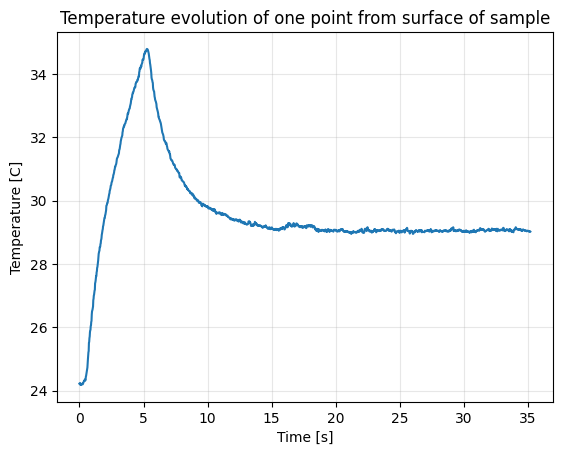

In [46]:
T,H,W=data['data'].shape
H_center=H//2
W_center=W//2

x_t=data['data'][:,H_center,W_center]/100-273.5 # Conversion to the [C]
x_t=torch.from_numpy(x_t).to(torch.float32)

t=torch.linspace(0,T/50.0,T) # Seconds of recordings [s]

plt.plot(t,x_t)
plt.grid(alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Temperature [C]')
plt.title('Temperature evolution of one point from surface of sample')

In [45]:
# ambient from initial frames
T_inf = x_t[:6].mean()
print(f'Estimated room temperature {T_inf}')

theta = x_t - T_inf # Removal of baseline

# cut cooling phase AFTER this
t_peak_idx = torch.argmax(theta)
print(f"Index for cooling stage: {t_peak_idx}")
t_cool = t[t_peak_idx:] # time vector
theta_cool = theta[t_peak_idx:] # Cooling stage of data

Estimated room temperature 24.209999084472656
Index for cooling stage: 263
